In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ic272_lab5_rent.csv")

In [3]:
df.shape

(300, 14)

In [4]:
df.isnull().sum()

area           0
rooms          0
age            0
dist_km        0
floors         0
noise_a        0
noise_b        0
noise_c        0
noise_d        0
noise_id       0
noise_tiny1    0
noise_tiny2    0
noise_tiny3    0
rent           0
dtype: int64

In [23]:
print(f"{'Features':14s}{'Min val':>13s}{'Max val':>13}")

for feat , mn , mx in zip(df.columns , df.min() , df.max()):
    print(f"{feat:14s}{mn:>13.6f}{mx:>13.6f}")

Features            Min val      Max val
area               5.050000     9.500000
rooms              1.000000     5.000000
age                0.000000     7.950000
dist_km            1.020000     8.910000
floors             1.000000     3.000000
noise_a           -5.566000     6.722000
noise_b           -6.498000     6.346000
noise_c           -5.606000     6.197000
noise_d           -5.927000     5.875000
noise_id      100026.300000104986.600000
noise_tiny1       -0.145810     0.150300
noise_tiny2       -0.122340     0.123490
noise_tiny3       -0.138490     0.116580
rent              29.550000    85.940000


In [5]:
features = [ i for i in df.columns if i != "rent"]

In [9]:
x = df[features].to_numpy(float)
y = df["rent"].to_numpy(float)

In [25]:
x.shape

(300, 13)

In [26]:
y.shape

(300,)

In [27]:
def train_test_split(x,y,test_size,seed):

    n = len(y)

    rng = np.random.default_rng(seed)

    idx = rng.permutation(n)

    n_test = int(n*test_size)

    train_idx = idx[n_test :]
    test_idx = idx[:n_test]

    return (x[train_idx] , x[test_idx] , y[train_idx] , y[test_idx])

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    seed=0
)

In [35]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (240, 13)
X_test shape: (60, 13)
y_train shape: (240,)
y_test shape: (60,)


In [36]:
def fit_simple_lr(x,y):

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numr = np.sum(
        (x-x_mean)*(y-y_mean)
    )

    denr = np.sum(
        (x-x_mean)**2
    )

    w = numr/denr
    b = y_mean - w*x_mean

    return w,b

In [37]:
x_train_area = x_train[:,0]

In [41]:
w , b = fit_simple_lr(
    x_train_area , y_train
)

print(f"w = {w:4f}")
print(f"b : {b:4f}")

w = 5.920584
b : 11.572232


In [42]:
x_test_area = x_test[:,0]
y_pred = w*x_test_area + b

In [43]:
sort_idx = np.argsort(x_test_area)

x_sorted = x_test_area[sort_idx]
y_line = y_pred[sort_idx]

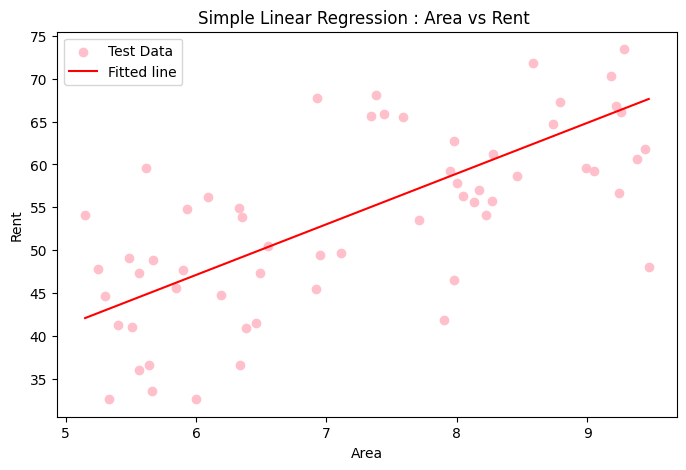

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(
    x_test_area,
    y_test,
    label = "Test Data",
    color = "pink"
)

plt.plot(
    x_sorted,
    y_line,
    label = "Fitted line",
    color = "r"
)

plt.xlabel("Area")
plt.ylabel("Rent")
plt.title("Simple Linear Regression : Area vs Rent ")
plt.legend()

plt.show()

In [46]:
def design_matrix(x):
    return np.c_[np.ones(len(x)),x]

In [47]:
def fit_normal_eqn(x,y):

    A = design_matrix(x)

    theta = np.linalg.solve(A.T@A , A.T@y)

    return theta 

In [48]:
theta_ne = fit_normal_eqn(
    x_train , y_train
)
print(f"Normal Equation Parameter : {theta_ne}")

Normal Equation Parameter : [ 7.79645272e+00  6.04184673e+00  3.23055935e+00 -1.37156719e+00
 -1.80893278e+00  1.83989407e+00  1.20215892e-01  3.61214570e-03
  1.67004812e-01 -1.49378341e-01  3.64024735e-05 -4.64999398e+00
 -8.68425905e+00 -2.25881036e+00]


In [50]:
params = [
    "intercept",
    "area",
    "rooms",
    "age",
    "dist",
    "floors"
]

print(f"{params:13s}{theta_ne:>13s}")

for pm , val in zip(params,theta_ne):
    print(f"{pm:<13}{val:4f}")

TypeError: unsupported format string passed to list.__format__

In [10]:
idx = np.random.default_rng(0).permutation(len(y))

In [11]:
tr , te = idx[:40] , idx[40:]
x_train , x_test = x[tr] , x[te]
y_train , y_test = y[tr] , y[te]

In [12]:
x.shape

(300, 13)

In [13]:
x_train.shape

(40, 13)

In [14]:
x_test.shape

(260, 13)

In [15]:
def design_matrix(x):

    return np.c_[np.ones(len(x)),x]

In [16]:
def fit_normal_equation(x,y):
    A = design_matrix(x)
    return np.linalg.solve(A.T@A , A.T@y)

In [49]:
theta_raw = fit_normal_equation(x_train,y_train)
print(theta_raw)

[ 7.79645272e+00  6.04184673e+00  3.23055935e+00 -1.37156719e+00
 -1.80893278e+00  1.83989407e+00  1.20215892e-01  3.61214570e-03
  1.67004812e-01 -1.49378341e-01  3.64024735e-05 -4.64999398e+00
 -8.68425905e+00 -2.25881036e+00]


In [21]:
print(f"{'feature':14s}{'coefficient':>13}{'column sd':>12}")

for feat, coef, sd in zip(features, theta_raw[1:], x.std(axis=0)):
    print(f"{feat:14s}{coef:>13.6f}{sd:>12.6f}")

feature         coefficient   column sd
area               6.203491    1.276070
rooms              3.565093    1.422845
age               -1.488932    2.195416
dist_km           -2.147842    2.315945
floors             1.914922    0.816388
noise_a           -0.444267    2.021746
noise_b           -0.181942    1.970590
noise_c           -0.399040    2.083478
noise_d            0.108700    2.019355
noise_id          -0.000427 1473.122250
noise_tiny1      -11.221004    0.050803
noise_tiny2       -6.369551    0.047689
noise_tiny3      -11.992788    0.047663
